<a href="https://colab.research.google.com/github/hanshunyi0-cyber/mlp-s5-case-study/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s5-blood-cells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Cell Classification — starter notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s5-blood-cells.ipynb)

Classify microscopy images of **blood cells** into one of **8 cell types**, from
28×28 RGB images: [challenge 173](https://ml-arena.com/viewchallenge/173) on ML-Arena.

This notebook runs end-to-end: **download the data → look at it → train a simple model → submit**.
Metric: **F1-macro**.

> Open in Colab, then run the cells top to bottom. The only thing you must edit is
> your API token in the next cell (find it on your **Profile** page on ml-arena.com).

## 0. Setup

In [1]:
!pip install -q "mlarena-sdk>=3" scikit-learn pandas numpy   # installs the `mlarena` package

import mlarena
import numpy as np
import pandas as pd
from google.colab import userdata

API_TOKEN = userdata.get("MLARENA_API_KEY")   # <-- paste your token (Profile page)
CHALLENGE_ID = 173

client = mlarena.connect(api_key=API_TOKEN, base_url="https://ml-arena.com")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 4.0 MB/s eta 0:00:00


## 1. Get the data

`download_dataset` pulls the challenge files into `data/`. Each image is a
`28 × 28 × 3` (RGB) array; the training labels are in `y_train.csv` (`image_id,label`).

In [2]:
client.download_dataset(CHALLENGE_ID, "data/")

train = np.load("data/train_images.npz")   # train["image_id"], train["images"] (N,28,28,3) uint8
test  = np.load("data/test_images.npz")    # test["image_id"],  test["images"]
y_train = pd.read_csv("data/y_train.csv")  # image_id,label

# line up each image with its label (match on image_id, don't assume row order)
label_of = y_train.set_index("image_id")["label"]
y = label_of.loc[train["image_id"]].values

print("train images:", train["images"].shape, "  test images:", test["images"].shape)
print(pd.Series(y).value_counts())

train images: (13673, 28, 28, 3)   test images: (3419, 28, 28, 3)
cell_C    2663
cell_B    2494
cell_F    2316
cell_A    1878
cell_D    1241
cell_H    1136
cell_G     974
cell_E     971
Name: count, dtype: int64


## 2. Look at the images

Six random training images per class, one row per cell type, with the number of
training images of that class. The rows differ in nucleus shape, granularity and
stain colour; the counts show how unbalanced the classes are, which is why the
metric is F1-macro.


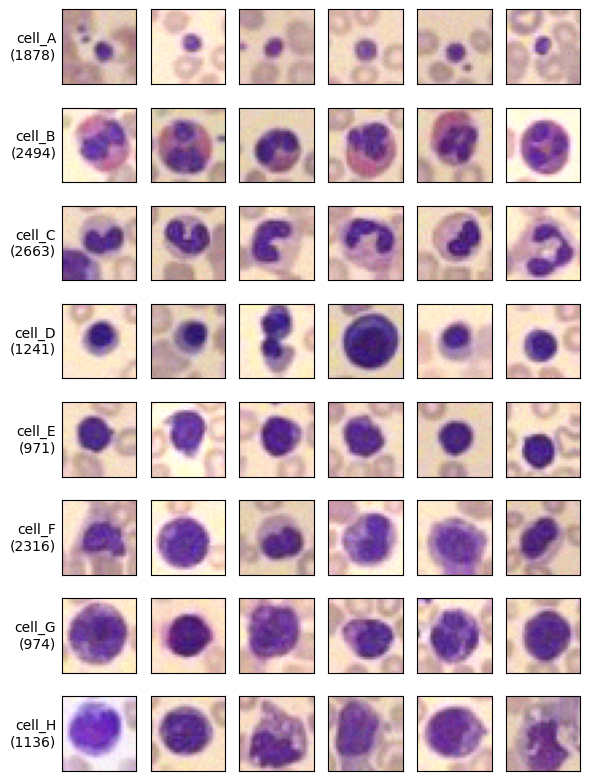

In [3]:
import matplotlib.pyplot as plt

classes = sorted(np.unique(y))
rng = np.random.default_rng(0)
fig, axes = plt.subplots(len(classes), 6, figsize=(6, len(classes)))
for row, cls in zip(axes, classes):
    idx = rng.choice(np.flatnonzero(y == cls), size=6, replace=False)
    for ax, i in zip(row, idx):
        ax.imshow(train["images"][i])
        ax.set_xticks([]); ax.set_yticks([])
    row[0].set_ylabel(f"{cls}\n({(y == cls).sum()})", rotation=0, ha="right", va="center")
plt.tight_layout()
plt.show()


## 3. A baseline model

Flatten each image into a vector of pixels and fit a random forest. This is just a
starting point — a small CNN (e.g. PyTorch) trained on the raw images will score
much higher. We hold out 20% to estimate the F1-macro before submitting.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X = train["images"].reshape(len(train["images"]), -1) / 255.0   # (N, 28*28*3)
X_test = test["images"].reshape(len(test["images"]), -1) / 255.0

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)
clf.fit(X_tr, y_tr)
print("validation F1-macro: %.4f" % f1_score(y_val, clf.predict(X_val), average="macro"))

clf.fit(X, y)   # refit on all the training data before predicting the test set

validation F1-macro: 0.7315


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)

## 4. Predict and write `submission.csv`

In [5]:
pred = clf.predict(X_test)
submission = pd.DataFrame({"image_id": test["image_id"], "label": pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,image_id,label
0,img_002591,cell_C
1,img_001828,cell_D
2,img_015622,cell_G
3,img_010608,cell_F
4,img_008013,cell_F


## 5. Submit

Run the cell below to submit through the SDK, or upload `submission.csv` on the
challenge page.

In [6]:
result = client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"])
print(result)

{'submission_id': 9050, 'deploy': {'deployment_id': 8764, 'is_deployable': False, 'is_settled': False, 'is_uploadable': False, 'last_status_message': 'Deployment queued successfully', 'message': 'Deployment started successfully', 'phase': 'deployment', 'status': 'deploy_queue', 'status_update_ts': '2026-09-28T13:24:23.616417Z'}}


## 6. Where to go from here

The pixel-flattening baseline throws away the *spatial* structure of the image — that's
where most of the score is hiding. Work one step at a time: **change one thing → watch the
validation F1 → submit only if it improved.** Trust the held-out number, not the train score.

- **Look at more images.** Rerun the grid of section 2 with other seeds and look for anything odd — blurry crops, near-duplicates,
  mislabeled cells. F1-macro weights every class equally, so the rare ones matter most.

- **Train a small CNN (PyTorch).** A couple of conv + pooling layers already beats the random
  forest by a wide margin, because convolutions exploit the 2-D layout the baseline discards.
  Normalize inputs to `[0, 1]` (or per-channel mean/std) and use cross-entropy loss.

- **Train carefully.** Keep a stratified validation split and watch it every epoch.
  - *Learning rate* is the single most important knob — try a few values (e.g. 1e-2 … 1e-4).
  - Use **early stopping** and save the best-validation checkpoint.
  - Tune batch size and epochs; add dropout or weight decay if you overfit.

- **Augment the data.** Random flips, small rotations, and mild color jitter make the model
  robust to orientation and staining differences — cheap and almost always helps on microscopy.

- **Use a pretrained model.** Load a network pretrained on ImageNet (ResNet, EfficientNet, …),
  resize the 28×28 crops to its expected input, and **fine-tune** it on these cells. This is
  usually the biggest jump for the least effort.

Watch train vs. validation: if validation stalls while train keeps improving, you're
overfitting — stop early, augment more, or regularize.


In [3]:
%pip -q install 'mlarena-sdk>=3' scikit-learn pandas numpy matplotlib pillow torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 8.0 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import copy
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SEED = 0
CHALLENGE_ID = 173
DATA_DIR = Path('data')
ARTIFACT_DIR = Path('artifacts')
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

required = [DATA_DIR / name for name in ('train_images.npz', 'test_images.npz', 'y_train.csv')]
if not all(path.exists() for path in required):
    from google.colab import userdata
    import mlarena
    api_key = userdata.get('MLARENA_API_KEY')
    if not api_key:
        raise RuntimeError('请先把 MLARENA_API_KEY 存入 Colab 密钥，或上传三个数据文件到 data/')
    client = mlarena.connect(api_key=api_key, base_url='https://ml-arena.com')
    client.download_dataset(CHALLENGE_ID, str(DATA_DIR) + '/')
assert all(path.exists() for path in required), f'缺少数据文件：{[str(p) for p in required if not p.exists()]}'

with np.load(DATA_DIR / 'train_images.npz') as train_npz:
    train_ids = train_npz['image_id'].astype(str)
    train_images = train_npz['images'].copy()
with np.load(DATA_DIR / 'test_images.npz') as test_npz:
    test_ids = test_npz['image_id'].astype(str)
    test_images = test_npz['images'].copy()
labels = pd.read_csv(DATA_DIR / 'y_train.csv')
assert list(labels.columns) == ['image_id', 'label']
labels['image_id'] = labels['image_id'].astype(str)
assert labels['image_id'].is_unique and len(set(train_ids)) == len(train_ids)
assert len(set(test_ids)) == len(test_ids)
assert set(train_ids) == set(labels['image_id'])
assert train_images.shape[1:] == test_images.shape[1:] == (28, 28, 3)
assert train_images.dtype == test_images.dtype == np.uint8
assert len(train_images) == 13673 and len(test_images) == 3419, '数据规模与本题不符'
y_names = labels.set_index('image_id').loc[train_ids, 'label'].to_numpy()
classes = sorted(np.unique(y_names))
assert len(classes) == 8
class_to_idx = {name: i for i, name in enumerate(classes)}
y = np.array([class_to_idx[name] for name in y_names], dtype=np.int64)
train_idx, val_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=SEED, stratify=y
)
print('train:', train_images.shape, 'test:', test_images.shape)
print('classes:', classes)
print(pd.Series(y_names).value_counts().sort_index())

device: cuda
train: (13673, 28, 28, 3) test: (3419, 28, 28, 3)
classes: ['cell_A', 'cell_B', 'cell_C', 'cell_D', 'cell_E', 'cell_F', 'cell_G', 'cell_H']
cell_A    1878
cell_B    2494
cell_C    2663
cell_D    1241
cell_E     971
cell_F    2316
cell_G     974
cell_H    1136
Name: count, dtype: int64


In [5]:
X = train_images.reshape(len(train_images), -1) / 255.0
baseline = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
baseline.fit(X[train_idx], y[train_idx])
baseline_pred = baseline.predict(X[val_idx])
baseline_f1 = f1_score(y[val_idx], baseline_pred, average='macro')
print(f'本次运行的随机森林验证 F1-macro: {baseline_f1:.4f}')
baseline_report = classification_report(
    y[val_idx], baseline_pred, labels=np.arange(len(classes)),
    target_names=classes, output_dict=True, zero_division=0
)
display(pd.DataFrame(baseline_report).T.loc[classes, ['precision', 'recall', 'f1-score', 'support']])


本次运行的随机森林验证 F1-macro: 0.7315


,precision,recall,f1-score,support
cell_A,0.989160,0.970745,0.979866,376.0
cell_B,0.854932,0.885772,0.870079,499.0
cell_C,0.812092,0.932458,0.868122,533.0
cell_D,0.832558,0.721774,0.773218,248.0
cell_E,0.728205,0.731959,0.730077,194.0
cell_F,0.578100,0.775378,0.662362,463.0
cell_G,0.685185,0.379487,0.488449,195.0
cell_H,0.795918,0.343612,0.480000,227.0


/tmp/ipykernel_648/414868385.py:13: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_648/414868385.py:13: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_648/414868385.py:13: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_648/414868385.py:13: UserWarning: Glyph 25277 (\N{CJK UNIFIED IDEOGRAPH-62BD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_648/414868385.py:13: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_648/414868385.py:13: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEO

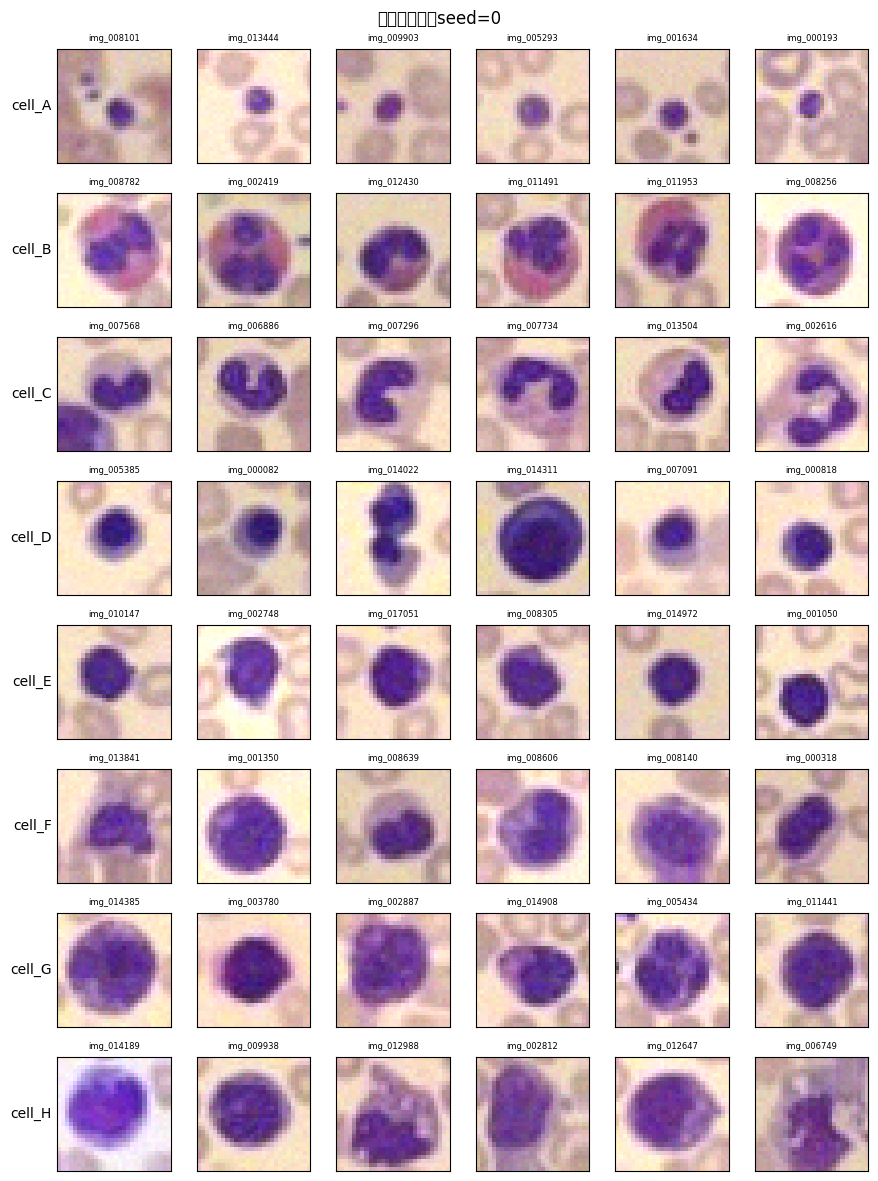

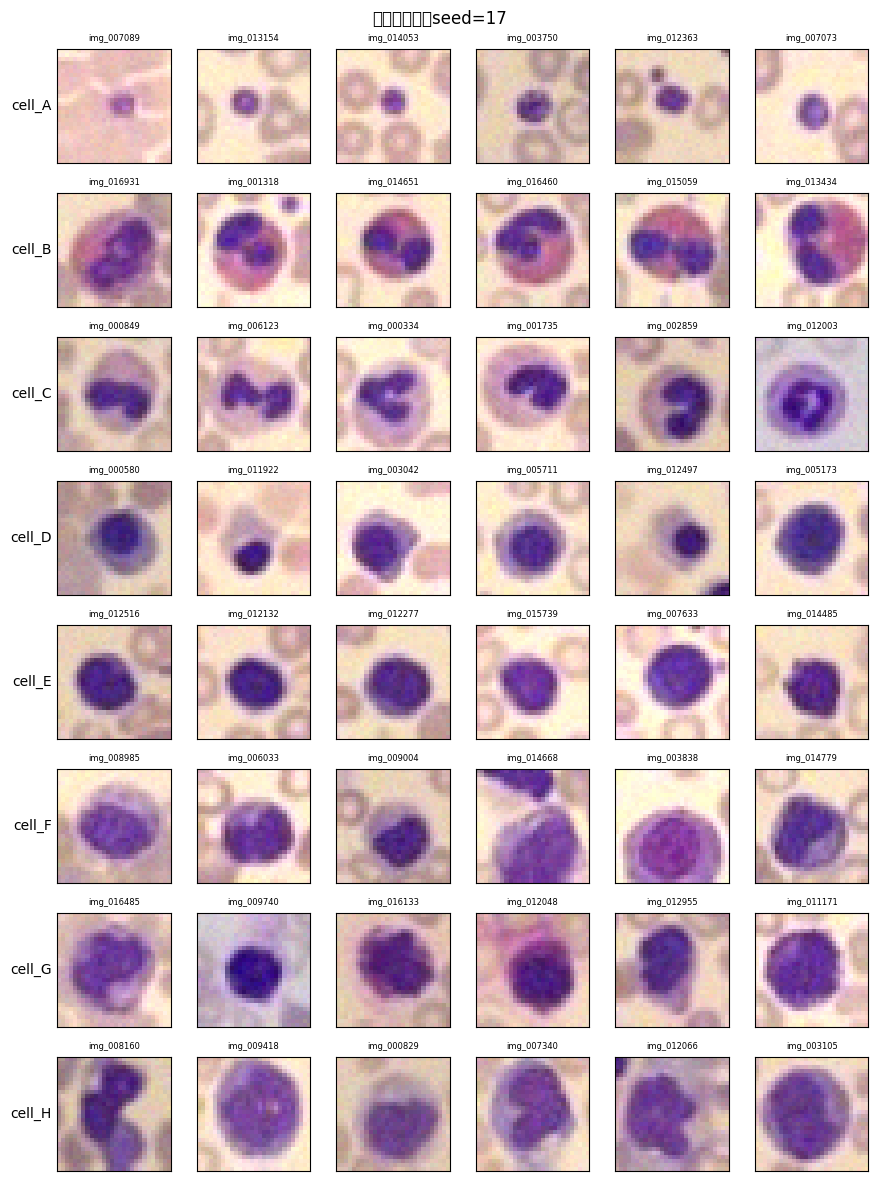

记录可疑 image_id 供人工复核；本 notebook 不自动更改标签。


In [6]:
for image_seed in (0, 17):
    rng = np.random.default_rng(image_seed)
    fig, axes = plt.subplots(len(classes), 6, figsize=(9, 1.5 * len(classes)))
    for row, class_name in enumerate(classes):
        candidates = np.flatnonzero(y == class_to_idx[class_name])
        chosen = rng.choice(candidates, size=6, replace=False)
        for ax, i in zip(axes[row], chosen):
            ax.imshow(train_images[i])
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(train_ids[i], fontsize=6)
        axes[row, 0].set_ylabel(class_name, rotation=0, ha='right', va='center')
    fig.suptitle(f'按类别抽样，seed={image_seed}')
    plt.tight_layout()
    plt.show()
print('记录可疑 image_id 供人工复核；本 notebook 不自动更改标签。')

In [7]:
class CellDataset(Dataset):
    def __init__(self, images, indices, transform, targets=None):
        self.images = images
        self.indices = np.asarray(indices)
        self.transform = transform
        self.targets = targets

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        i = int(self.indices[position])
        x = self.transform(Image.fromarray(self.images[i]))
        if self.targets is None:
            return x
        return x, int(self.targets[i])

cnn_plain = transforms.ToTensor()
cnn_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, fill=(255, 255, 255)),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08),
    transforms.ToTensor(),
])
resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_plain = resnet_weights.transforms()
resnet_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, fill=(255, 255, 255)),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def make_loader(images, indices, transform, targets=None, shuffle=False, batch_size=128):
    return DataLoader(
        CellDataset(images, indices, transform, targets),
        batch_size=batch_size, shuffle=shuffle, num_workers=2,
        pin_memory=DEVICE.type == 'cuda',
    )

class SmallCNN(nn.Module):
    def __init__(self, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, n_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

def make_resnet():
    model = models.resnet18(weights=resnet_weights)
    model.fc = nn.Linear(model.fc.in_features, len(classes))
    return model

def set_resnet_trainable(model, stage):
    for parameter in model.parameters():
        parameter.requires_grad = False
    if stage == 'head':
        modules = [model.fc]
    elif stage == 'last_block':
        modules = [model.layer4, model.fc]
    else:
        raise ValueError(stage)
    for module in modules:
        for parameter in module.parameters():
            parameter.requires_grad = True

def train_epoch(model, loader, optimizer, freeze_bn=False):
    model.train()
    if freeze_bn:
        for module in model.modules():
            if isinstance(module, nn.modules.batchnorm._BatchNorm):
                module.eval()
    loss_sum = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = nn.functional.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * len(yb)
    return loss_sum / len(loader.dataset)

@torch.inference_mode()
def predict(model, loader):
    model.eval()
    predictions = []
    for batch in loader:
        xb = batch[0] if isinstance(batch, (tuple, list)) else batch
        predictions.append(model(xb.to(DEVICE, non_blocking=True)).argmax(1).cpu().numpy())
    return np.concatenate(predictions)

def fit_with_validation(name, model, train_transform, val_transform, lr, max_epochs, patience,
                        weight_decay=1e-4, freeze_bn=False):
    seed_everything()
    model = model.to(DEVICE)
    train_loader = make_loader(train_images, train_idx, train_transform, y, shuffle=True)
    val_loader = make_loader(train_images, val_idx, val_transform, y)
    optimizer = torch.optim.AdamW(
        (p for p in model.parameters() if p.requires_grad), lr=lr, weight_decay=weight_decay
    )
    checkpoint = ARTIFACT_DIR / f'{name}.pt'
    best_f1, best_epoch, stale = -1.0, 0, 0
    history = []
    for epoch in range(1, max_epochs + 1):
        loss = train_epoch(model, train_loader, optimizer, freeze_bn)
        pred = predict(model, val_loader)
        score = f1_score(y[val_idx], pred, average='macro')
        history.append({'model': name, 'epoch': epoch, 'train_loss': loss, 'val_f1_macro': score})
        print(f'{name} epoch {epoch:02d}: loss={loss:.4f} val F1={score:.4f}')
        if score > best_f1 + 1e-6:
            best_f1, best_epoch, stale = score, epoch, 0
            torch.save(model.state_dict(), checkpoint)
        else:
            stale += 1
            if stale >= patience:
                break
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE, weights_only=True))
    pred = predict(model, val_loader)
    assert np.isclose(f1_score(y[val_idx], pred, average='macro'), best_f1)
    return {'name': name, 'val_f1_macro': best_f1, 'best_epoch': best_epoch,
            'checkpoint': str(checkpoint), 'pred': pred, 'history': history}

results = []

In [8]:
for lr in (1e-2, 1e-3, 1e-4):
    seed_everything()
    name = f'cnn_lr_{lr:.0e}'
    run = fit_with_validation(name, SmallCNN(len(classes)), cnn_plain, cnn_plain,
                              lr=lr, max_epochs=50, patience=8)
    run.update({'family': 'cnn', 'lr': lr, 'augmented': False})
    results.append(run)
plain_cnn_best = max((r for r in results if r['family'] == 'cnn'),
                     key=lambda r: r['val_f1_macro'])
print('最佳无增强 CNN:', plain_cnn_best['name'], plain_cnn_best['val_f1_macro'])

cnn_lr_1e-02 epoch 01: loss=0.7808 val F1=0.6351
cnn_lr_1e-02 epoch 02: loss=0.4739 val F1=0.4964
cnn_lr_1e-02 epoch 03: loss=0.3965 val F1=0.1687
cnn_lr_1e-02 epoch 04: loss=0.3454 val F1=0.6281
cnn_lr_1e-02 epoch 05: loss=0.3008 val F1=0.1989
cnn_lr_1e-02 epoch 06: loss=0.2534 val F1=0.7841
cnn_lr_1e-02 epoch 07: loss=0.2391 val F1=0.7314
cnn_lr_1e-02 epoch 08: loss=0.2168 val F1=0.6289
cnn_lr_1e-02 epoch 09: loss=0.2133 val F1=0.7898
cnn_lr_1e-02 epoch 10: loss=0.1871 val F1=0.6366
cnn_lr_1e-02 epoch 11: loss=0.1654 val F1=0.8153
cnn_lr_1e-02 epoch 12: loss=0.1564 val F1=0.7938
cnn_lr_1e-02 epoch 13: loss=0.1328 val F1=0.5539
cnn_lr_1e-02 epoch 14: loss=0.1222 val F1=0.7829
cnn_lr_1e-02 epoch 15: loss=0.1183 val F1=0.5591
cnn_lr_1e-02 epoch 16: loss=0.1012 val F1=0.6131
cnn_lr_1e-02 epoch 17: loss=0.0897 val F1=0.6431
cnn_lr_1e-02 epoch 18: loss=0.0911 val F1=0.8234
cnn_lr_1e-02 epoch 19: loss=0.0792 val F1=0.8577
cnn_lr_1e-02 epoch 20: loss=0.0621 val F1=0.8487
cnn_lr_1e-02 epoch 2

In [9]:
seed_everything()
aug_run = fit_with_validation(
    'cnn_augmented', SmallCNN(len(classes)), cnn_aug, cnn_plain,
    lr=plain_cnn_best['lr'], max_epochs=50, patience=8,
)
aug_run.update({'family': 'cnn', 'lr': plain_cnn_best['lr'], 'augmented': True})
results.append(aug_run)
print('增强前:', plain_cnn_best['val_f1_macro'], '增强后:', aug_run['val_f1_macro'])


cnn_augmented epoch 01: loss=0.8275 val F1=0.5650
cnn_augmented epoch 02: loss=0.5216 val F1=0.6791
cnn_augmented epoch 03: loss=0.4411 val F1=0.5884
cnn_augmented epoch 04: loss=0.3916 val F1=0.6602
cnn_augmented epoch 05: loss=0.3476 val F1=0.6658
cnn_augmented epoch 06: loss=0.3184 val F1=0.6792
cnn_augmented epoch 07: loss=0.3059 val F1=0.7822
cnn_augmented epoch 08: loss=0.2903 val F1=0.6198
cnn_augmented epoch 09: loss=0.2968 val F1=0.6458
cnn_augmented epoch 10: loss=0.2716 val F1=0.6704
cnn_augmented epoch 11: loss=0.2620 val F1=0.8008
cnn_augmented epoch 12: loss=0.2517 val F1=0.7987
cnn_augmented epoch 13: loss=0.2455 val F1=0.8467
cnn_augmented epoch 14: loss=0.2317 val F1=0.7613
cnn_augmented epoch 15: loss=0.2284 val F1=0.6957
cnn_augmented epoch 16: loss=0.2153 val F1=0.8659
cnn_augmented epoch 17: loss=0.2092 val F1=0.8957
cnn_augmented epoch 18: loss=0.2050 val F1=0.8177
cnn_augmented epoch 19: loss=0.2075 val F1=0.8376
cnn_augmented epoch 20: loss=0.1948 val F1=0.7989


In [10]:
seed_everything()
transfer = make_resnet()
set_resnet_trainable(transfer, 'head')
head_run = fit_with_validation(
    'resnet_head', transfer, resnet_aug, resnet_plain,
    lr=1e-3, max_epochs=12, patience=4, freeze_bn=True,
)
head_run.update({'family': 'resnet_head', 'lr': 1e-3, 'augmented': True})
results.append(head_run)

set_resnet_trainable(transfer, 'last_block')
fine_run = fit_with_validation(
    'resnet_last_block', transfer, resnet_aug, resnet_plain,
    lr=1e-4, max_epochs=20, patience=6, freeze_bn=True,
)
fine_run.update({'family': 'resnet_last_block', 'lr': 1e-4, 'augmented': True,
                 'head_epochs': head_run['best_epoch']})
results.append(fine_run)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


resnet_head epoch 01: loss=1.3406 val F1=0.4918
resnet_head epoch 02: loss=0.9563 val F1=0.5629
resnet_head epoch 03: loss=0.8422 val F1=0.6020
resnet_head epoch 04: loss=0.7824 val F1=0.5734
resnet_head epoch 05: loss=0.7369 val F1=0.5979
resnet_head epoch 06: loss=0.7145 val F1=0.6075
resnet_head epoch 07: loss=0.6894 val F1=0.6139
resnet_head epoch 08: loss=0.6664 val F1=0.6231
resnet_head epoch 09: loss=0.6566 val F1=0.6382
resnet_head epoch 10: loss=0.6485 val F1=0.6218
resnet_head epoch 11: loss=0.6354 val F1=0.6418
resnet_head epoch 12: loss=0.6152 val F1=0.6359
resnet_last_block epoch 01: loss=0.6583 val F1=0.7218
resnet_last_block epoch 02: loss=0.4111 val F1=0.7688
resnet_last_block epoch 03: loss=0.3584 val F1=0.7347
resnet_last_block epoch 04: loss=0.3138 val F1=0.7678
resnet_last_block epoch 05: loss=0.2766 val F1=0.8119
resnet_last_block epoch 06: loss=0.2493 val F1=0.7917
resnet_last_block epoch 07: loss=0.2450 val F1=0.8022
resnet_last_block epoch 08: loss=0.2193 val F1

In [11]:
summary = pd.DataFrame([
    {k: r.get(k) for k in ('name', 'family', 'lr', 'augmented', 'best_epoch', 'val_f1_macro')}
    for r in results
]).sort_values('val_f1_macro', ascending=False)
display(summary)
summary.to_csv(ARTIFACT_DIR / 'validation_results.csv', index=False)
pd.DataFrame([item for r in results for item in r['history']]).to_csv(
    ARTIFACT_DIR / 'training_history.csv', index=False
)
best = max(results, key=lambda r: r['val_f1_macro'])
IMPROVED = best['val_f1_macro'] > baseline_f1 + 1e-6
print(f'本次基线={baseline_f1:.4f}; 最佳模型={best["name"]}; 验证 F1={best["val_f1_macro"]:.4f}')
print('是否超过本次基线:', IMPROVED)
best_report = classification_report(
    y[val_idx], best['pred'], labels=np.arange(len(classes)),
    target_names=classes, output_dict=True, zero_division=0
)
per_class = pd.DataFrame({
    'class': classes,
    'baseline_f1': [baseline_report[c]['f1-score'] for c in classes],
    'best_f1': [best_report[c]['f1-score'] for c in classes],
    'support': [best_report[c]['support'] for c in classes],
})
display(per_class)
per_class.to_csv(ARTIFACT_DIR / 'per_class_f1.csv', index=False)


,name,family,lr,augmented,best_epoch,val_f1_macro
0,cnn_lr_1e-02,cnn,0.0100,False,40,0.919703
3,cnn_augmented,cnn,0.0100,True,17,0.895718
2,cnn_lr_1e-04,cnn,0.0001,False,38,0.888457
1,cnn_lr_1e-03,cnn,0.0010,False,9,0.875656
5,resnet_last_block,resnet_last_block,0.0001,True,16,0.858839
4,resnet_head,resnet_head,0.0010,True,11,0.641791


本次基线=0.7315; 最佳模型=cnn_lr_1e-02; 验证 F1=0.9197
是否超过本次基线: True


,class,baseline_f1,best_f1,support
0,cell_A,0.979866,0.996005,376.0
1,cell_B,0.870079,0.989899,499.0
2,cell_C,0.868122,0.970837,533.0
3,cell_D,0.773218,0.937120,248.0
4,cell_E,0.730077,0.937028,194.0
5,cell_F,0.662362,0.851064,463.0
6,cell_G,0.488449,0.844560,195.0
7,cell_H,0.480000,0.831111,227.0


In [12]:
def train_full(model, train_transform, epochs, lr, freeze_bn=False, weight_decay=1e-4):
    model = model.to(DEVICE)
    loader = make_loader(train_images, np.arange(len(y)), train_transform, y, shuffle=True)
    optimizer = torch.optim.AdamW(
        (p for p in model.parameters() if p.requires_grad), lr=lr, weight_decay=weight_decay
    )
    for epoch in range(1, epochs + 1):
        loss = train_epoch(model, loader, optimizer, freeze_bn)
        print(f'全量训练 {epoch:02d}/{epochs}: loss={loss:.4f}')
    return model

if not IMPROVED:
    print('没有方案超过本次基线：保留原提交，不生成新 submission.csv。')
else:
    seed_everything()
    if best['family'] == 'cnn':
        final_model = train_full(
            SmallCNN(len(classes)), cnn_aug if best['augmented'] else cnn_plain,
            best['best_epoch'], best['lr']
        )
        test_transform = cnn_plain
    else:
        final_model = make_resnet()
        set_resnet_trainable(final_model, 'head')
        head_epochs = (best['best_epoch'] if best['family'] == 'resnet_head'
                       else best['head_epochs'])
        final_model = train_full(final_model, resnet_aug, head_epochs, 1e-3, freeze_bn=True)
        if best['family'] == 'resnet_last_block':
            set_resnet_trainable(final_model, 'last_block')
            final_model = train_full(
                final_model, resnet_aug, best['best_epoch'], 1e-4, freeze_bn=True
            )
        test_transform = resnet_plain

    final_model_path = ARTIFACT_DIR / 'best_model.pt'
    torch.save({
        'state_dict': final_model.cpu().state_dict(), 'classes': classes,
        'family': best['family'], 'augmented': best['augmented'],
        'best_epoch': best['best_epoch'], 'validation_f1_macro': best['val_f1_macro'],
        'baseline_f1_macro': baseline_f1,
    }, final_model_path)
    final_model = final_model.to(DEVICE)
    test_loader = make_loader(test_images, np.arange(len(test_ids)), test_transform)
    predicted_indices = predict(final_model, test_loader)
    submission = pd.DataFrame({
        'image_id': test_ids,
        'label': [classes[int(i)] for i in predicted_indices],
    })
    assert len(submission) == len(test_ids)
    assert submission['image_id'].is_unique
    assert submission['image_id'].tolist() == test_ids.tolist()
    assert set(submission['label']).issubset(set(classes))
    assert not submission.isna().any().any()
    submission.to_csv('submission.csv', index=False)
    print('已保存:', final_model_path, '及 submission.csv')
    print('提交行数:', len(submission))
    display(submission.head())


全量训练 01/40: loss=0.7648
全量训练 02/40: loss=0.4376
全量训练 03/40: loss=0.3664
全量训练 04/40: loss=0.3129
全量训练 05/40: loss=0.2764
全量训练 06/40: loss=0.2510
全量训练 07/40: loss=0.2195
全量训练 08/40: loss=0.2118
全量训练 09/40: loss=0.1981
全量训练 10/40: loss=0.1795
全量训练 11/40: loss=0.1576
全量训练 12/40: loss=0.1419
全量训练 13/40: loss=0.1341
全量训练 14/40: loss=0.1160
全量训练 15/40: loss=0.1063
全量训练 16/40: loss=0.0947
全量训练 17/40: loss=0.0811
全量训练 18/40: loss=0.0754
全量训练 19/40: loss=0.0700
全量训练 20/40: loss=0.0546
全量训练 21/40: loss=0.0485
全量训练 22/40: loss=0.0584
全量训练 23/40: loss=0.0533
全量训练 24/40: loss=0.0428
全量训练 25/40: loss=0.0418
全量训练 26/40: loss=0.0544
全量训练 27/40: loss=0.0317
全量训练 28/40: loss=0.0322
全量训练 29/40: loss=0.0250
全量训练 30/40: loss=0.0113
全量训练 31/40: loss=0.0124
全量训练 32/40: loss=0.0200
全量训练 33/40: loss=0.0247
全量训练 34/40: loss=0.0467
全量训练 35/40: loss=0.0583
全量训练 36/40: loss=0.0282
全量训练 37/40: loss=0.0122
全量训练 38/40: loss=0.0130
全量训练 39/40: loss=0.0282
全量训练 40/40: loss=0.0229
已保存: artifacts/best_model.pt 及 submissio

,image_id,label
0,img_002591,cell_C
1,img_001828,cell_D
2,img_015622,cell_G
3,img_010608,cell_F
4,img_008013,cell_F


In [14]:
SUBMIT_TO_MLARENA = True
if SUBMIT_TO_MLARENA:
    if not IMPROVED or not Path('submission.csv').exists():
        raise RuntimeError('没有超过本次基线的有效提交文件。')
    import mlarena
    from google.colab import userdata
    api_key = userdata.get('MLARENA_API_KEY')
    if not api_key:
        raise RuntimeError('Colab 密钥中没有 MLARENA_API_KEY。')
    client = mlarena.connect(api_key=api_key, base_url='https://ml-arena.com')
    result = client.submit(challenge_id=CHALLENGE_ID, files=['submission.csv'])
    print(result)
else:
    print('未提交；检查结果后可手动启用提交。')


{'submission_id': 9063, 'deploy': {'deployment_id': 8775, 'is_deployable': False, 'is_settled': False, 'is_uploadable': False, 'last_status_message': 'Deployment queued successfully', 'message': 'Deployment started successfully', 'phase': 'deployment', 'status': 'deploy_queue', 'status_update_ts': '2026-09-28T14:42:00.981238Z'}}
